# Predicting Age from MRI-Derived Brain Measurements and Clinical Characteristics Using Machine Learning


## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

## 2. Load Final Modeling Dataset



In [5]:
df = pd.read_excel("OASIS-1.xlsx")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (436, 12)


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


## 3. Basic Cleaning and Target Definition

In [6]:
# Remove useless columns
df = df.drop(columns=["ID", "Hand", "Delay"])

# Convert gender to numeric
df["M/F"] = df["M/F"].map({
    "M": 1,
    "F": 0
})

# Remove rows with missing Age
df = df.dropna(subset=["Age"]).copy()

# Target variable
y = df["Age"]

print("Cleaned dataset shape:", df.shape)
print(y.describe())

Cleaned dataset shape: (436, 9)
count    436.000000
mean      51.357798
std       25.269862
min       18.000000
25%       23.000000
50%       54.000000
75%       74.000000
max       96.000000
Name: Age, dtype: float64


## 4. Feature Set


In [14]:
features = [
    "M/F",
    "Educ",
    "SES",
    "MMSE",
    "CDR",
    "eTIV",
    "nWBV",
    "ASF"
]

df_model = df[["Age"] + features].dropna()

print(df_model.shape)

(216, 9)


## 5. Dataset Overview and Missing Values

In [11]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   M/F     436 non-null    int64  
 1   Age     436 non-null    int64  
 2   Educ    235 non-null    float64
 3   SES     216 non-null    float64
 4   MMSE    235 non-null    float64
 5   CDR     235 non-null    float64
 6   eTIV    436 non-null    int64  
 7   nWBV    436 non-null    float64
 8   ASF     436 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 30.8 KB
None


In [12]:
missing = df.isnull().sum()
missing[missing > 0]

Educ    201
SES     220
MMSE    201
CDR     201
dtype: int64

## 6. Summary Statistics

In [15]:
summary_stats = df_model.describe()
summary_stats

,Age,M/F,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000
mean,72.444444,0.328704,3.231481,2.490741,27.324074,0.261574,1458.638889,0.750500,1.217176
std,12.306424,0.470833,1.333689,1.120593,3.436680,0.382593,160.523125,0.048271,0.128858
min,33.000000,0.000000,1.000000,1.000000,15.000000,0.000000,1123.000000,0.644000,0.881000
25%,66.000000,0.000000,2.000000,2.000000,26.000000,0.000000,1346.000000,0.715000,1.141750
50%,73.000000,0.000000,3.000000,2.000000,29.000000,0.000000,1445.500000,0.748500,1.214500
75%,81.000000,1.000000,4.000000,3.000000,30.000000,0.500000,1536.500000,0.786000,1.304000
max,96.000000,1.000000,5.000000,5.000000,30.000000,2.000000,1992.000000,0.841000,1.563000


## 7. Distribution of Age and Boxplot of Age

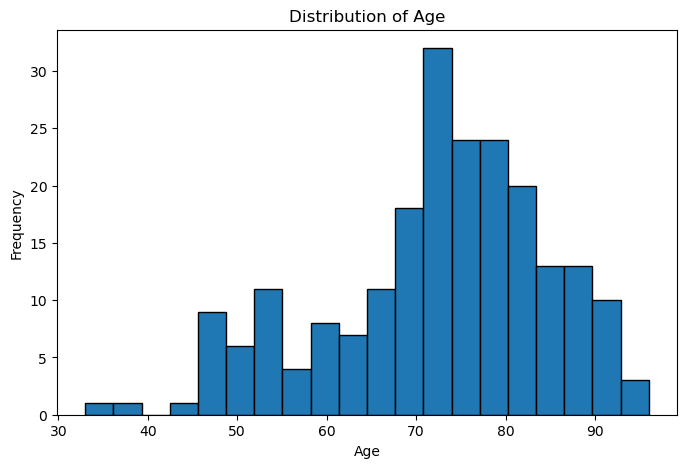

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df_model["Age"], bins=20, edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

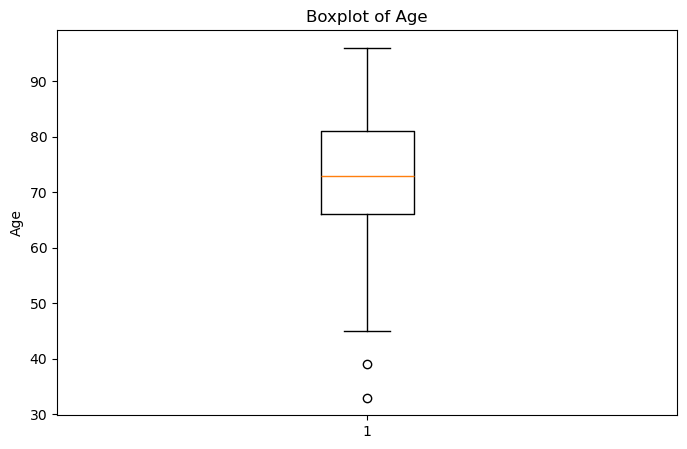

In [19]:
plt.figure(figsize=(8,5))
plt.boxplot(df_model["Age"])
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

## 8. Correlation Analysis

In [20]:
corr = df[["Age"] + features].corr(numeric_only=True)

corr_target = corr["Age"].sort_values(ascending=False)
corr_target

Age     1.000000
CDR     0.299969
SES     0.157806
ASF     0.137514
M/F    -0.100659
eTIV   -0.140984
Educ   -0.207094
MMSE   -0.252123
nWBV   -0.874100
Name: Age, dtype: float64

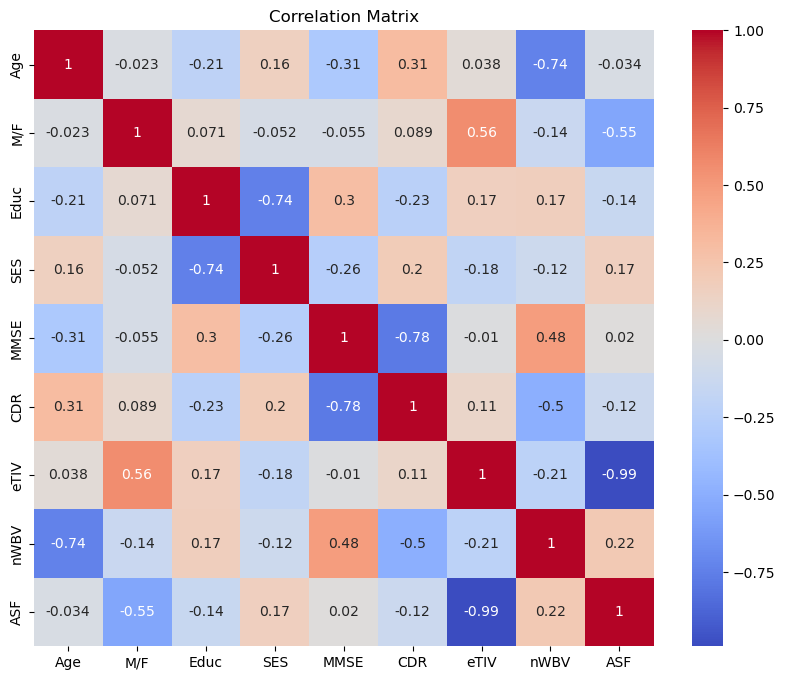

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df_model.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

## 9. Scatterplots of Selected MRI Features vs Age

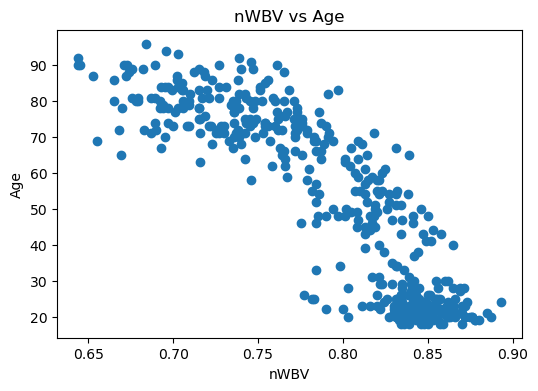

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(df["nWBV"], df["Age"])
plt.xlabel("nWBV")
plt.ylabel("Age")
plt.title("nWBV vs Age")
plt.show()

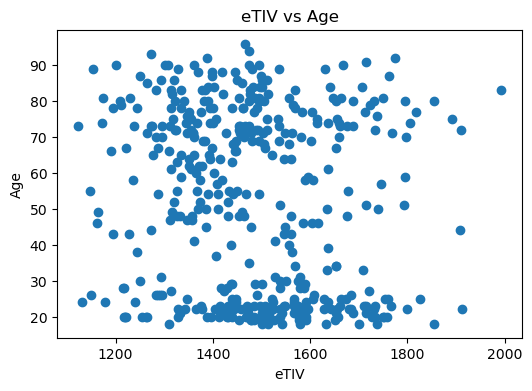

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(df["eTIV"], df["Age"])
plt.xlabel("eTIV")
plt.ylabel("Age")
plt.title("eTIV vs Age")
plt.show()

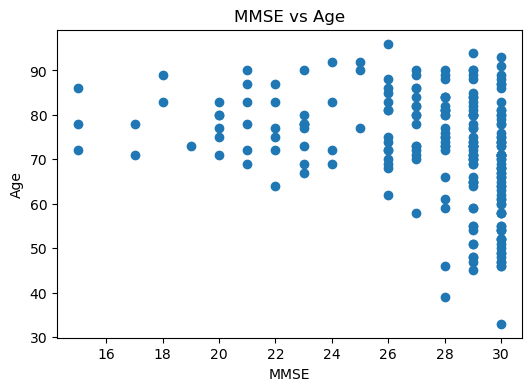

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(df_model["MMSE"], df_model["Age"])
plt.xlabel("MMSE")
plt.ylabel("Age")
plt.title("MMSE vs Age")
plt.show()

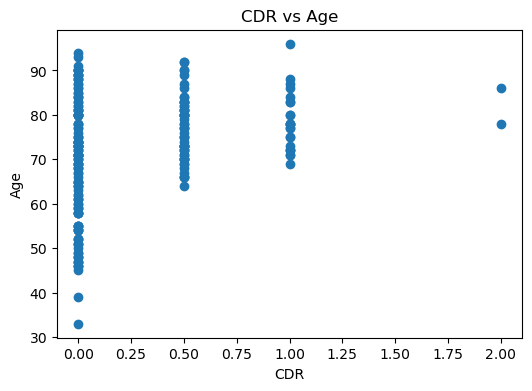

In [25]:
plt.figure(figsize=(6,4))
plt.scatter(df_model["CDR"], df_model["Age"])
plt.xlabel("CDR")
plt.ylabel("Age")
plt.title("CDR vs Age")
plt.show()

## 10. Multicollinearity Check Using VIF

VIF is calculated using the final predictor set. Very high VIF values suggest redundant predictors.

In [26]:
X_vif = X.copy()

# Remove constant columns if any exist.
X_vif = X_vif.loc[:, X_vif.nunique() > 1]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
6,nWBV,343.870389
3,MMSE,175.124510
7,ASF,165.679131
5,eTIV,145.143337
1,Educ,16.015986
2,SES,13.486265
4,CDR,3.886617
0,M/F,2.191896


## 11. Train/Test Split

The same split is used for all regression models for fair comparison.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 162
Testing rows: 54


## 12. LASSO Feature Selection

In [28]:
lasso_fs = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, max_iter=100000, random_state=42))
])

lasso_fs.fit(X, y)

coef = pd.Series(
    lasso_fs.named_steps["lasso"].coef_,
    index=X.columns
)

selected = coef[coef != 0].sort_values(key=abs, ascending=False)
selected

nWBV   -9.604747
M/F    -0.948897
ASF     0.827705
Educ   -0.709784
CDR    -0.514007
MMSE    0.507416
SES     0.222324
dtype: float64

## 13. Linear Regression

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 5.256541298567222
RMSE: 7.075114268730545
R2: 0.6542182675112436


## 14. Ridge Regression

In [30]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas))
])

ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

print("Ridge Regression")
print("Best Alpha:", ridge.named_steps["ridge"].alpha_)
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

Ridge Regression
Best Alpha: 10.0
MAE: 5.22625147187015
RMSE: 7.148701254839824
R2: 0.6469880351264858


## 15. LASSO Regression Model

This uses LASSO as a prediction model, not only as feature selection.

In [31]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, max_iter=100000, random_state=42))
])

lasso_model.fit(X_train, y_train)
pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)

print("LASSO Regression")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R2:", r2_lasso)

LASSO Regression
MAE: 5.282402414838348
RMSE: 7.179088274074937
R2: 0.6439805573764471


## 16. Decision Tree Regression

In [32]:
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

mae_tree = mean_absolute_error(y_test, pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, pred_tree))
r2_tree = r2_score(y_test, pred_tree)

print("Decision Tree")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

Decision Tree
MAE: 6.851260622093954
RMSE: 8.900388524959753
R2: 0.45279121716578075


In [33]:
tree_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
}).sort_values("Importance", ascending=False)

tree_importance.head(10)

,Feature,Importance
6,nWBV,0.825478
0,M/F,0.062997
5,eTIV,0.058987
2,SES,0.036225
3,MMSE,0.016314
1,Educ,0.000000
4,CDR,0.000000
7,ASF,0.000000


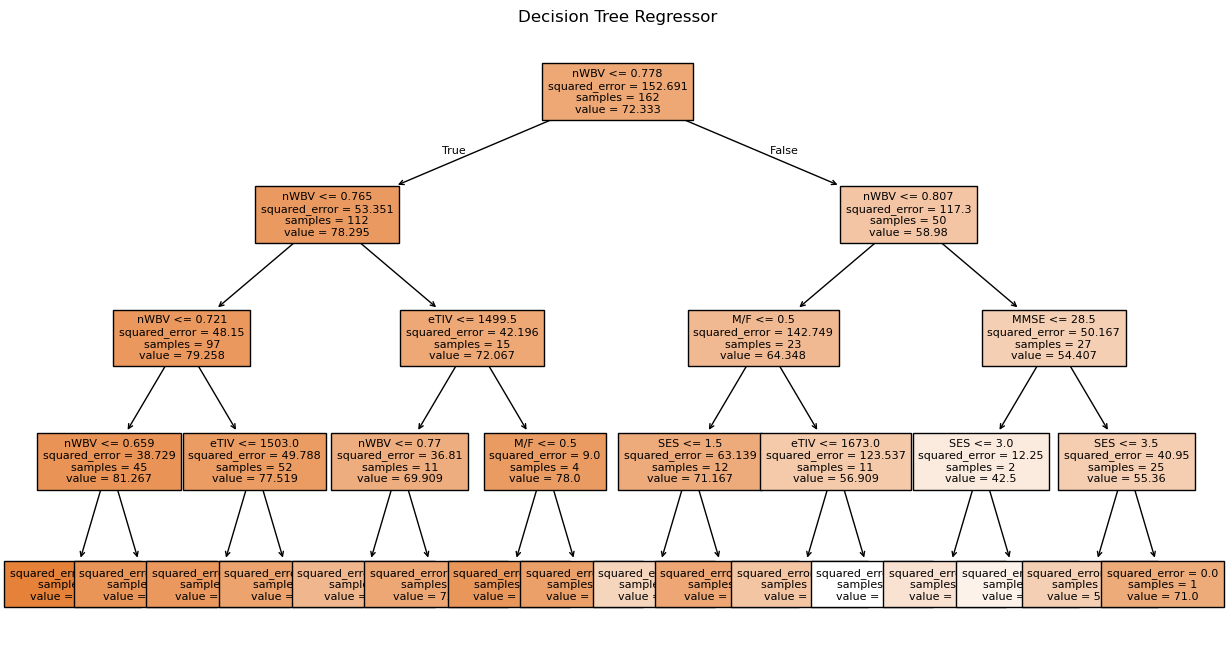

In [34]:
plt.figure(figsize=(15,8))
plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    fontsize=8
)
plt.title("Decision Tree Regressor")
plt.show()

## 17. Random Forest Regression

In [35]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest
MAE: 6.138222222222221
RMSE: 7.446349819181854
R2: 0.6169795176530786


In [36]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance.head(10)

,Feature,Importance
6,nWBV,0.695018
5,eTIV,0.066159
7,ASF,0.064985
3,MMSE,0.060075
2,SES,0.044396
1,Educ,0.034019
4,CDR,0.021006
0,M/F,0.014342


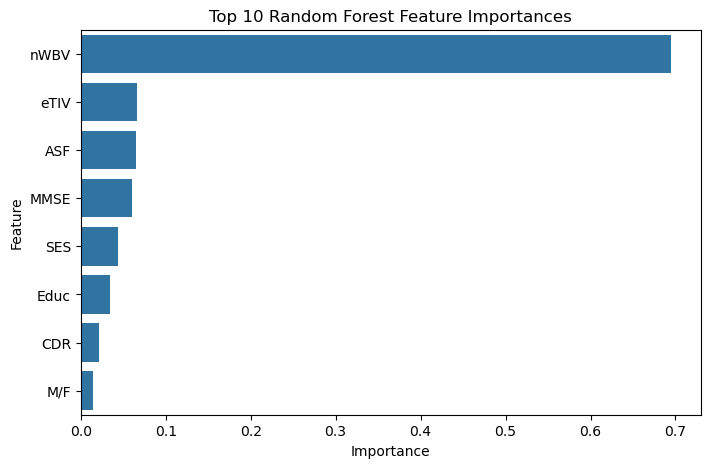

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=rf_importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 18. Tuned Random Forest Regression

In [38]:
rf_tuned = RandomForestRegressor(
    n_estimators=1000,
    max_depth=3,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)
pred_rf_tuned = rf_tuned.predict(X_test)

mae_rf_tuned = mean_absolute_error(y_test, pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, pred_rf_tuned)

print("Tuned Random Forest")
print("MAE:", mae_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R2:", r2_rf_tuned)

Tuned Random Forest
MAE: 5.782662431460589
RMSE: 6.983634974930623
R2: 0.6631021870621684


## 19. Model Comparison

In [39]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "LASSO Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_ridge,
        mae_lasso,
        mae_tree,
        mae_rf,
        mae_rf_tuned
    ],
    "RMSE": [
        rmse_lr,
        rmse_ridge,
        rmse_lasso,
        rmse_tree,
        rmse_rf,
        rmse_rf_tuned
    ],
    "R2": [
        r2_lr,
        r2_ridge,
        r2_lasso,
        r2_tree,
        r2_rf,
        r2_rf_tuned
    ]
})

model_results.sort_values("RMSE")

,Model,MAE,RMSE,R2
5,Tuned Random Forest,5.782662,6.983635,0.663102
0,Linear Regression,5.256541,7.075114,0.654218
1,Ridge Regression,5.226251,7.148701,0.646988
2,LASSO Regression,5.282402,7.179088,0.643981
4,Random Forest,6.138222,7.446350,0.616980
3,Decision Tree,6.851261,8.900389,0.452791


## 20. PCA Dimension Reduction

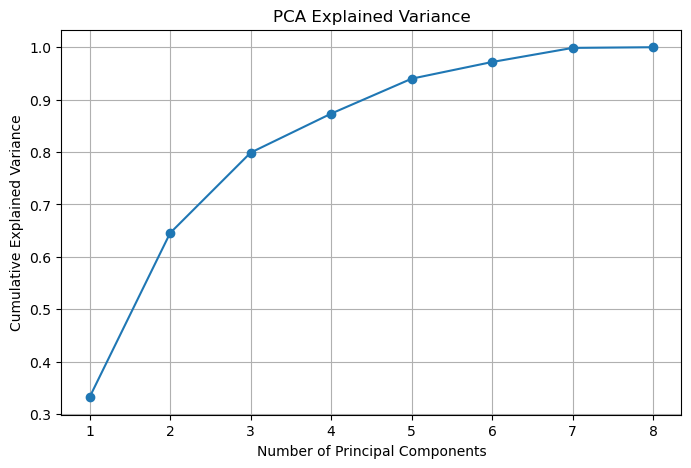

In [40]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cum_explained) + 1),
    cum_explained,
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [41]:
pca_table = pd.DataFrame({
    "PC": range(1, len(explained) + 1),
    "Variance Explained": explained,
    "Cumulative Variance": cum_explained
})

pca_table.head(10)

,PC,Variance Explained,Cumulative Variance
0,1,0.332328,0.332328
1,2,0.313134,0.645462
2,3,0.153391,0.798853
3,4,0.074463,0.873315
4,5,0.066665,0.939980
5,6,0.031852,0.971832
6,7,0.026907,0.998739
7,8,0.001261,1.000000


## 21. Generalized Linear Model (Gaussian GLM)

In [42]:
X_glm = sm.add_constant(X)

glm = sm.GLM(
    y,
    X_glm,
    family=sm.families.Gaussian()
)

glm_results = glm.fit()
print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    Age   No. Observations:                  216
Model:                            GLM   Df Residuals:                      207
Model Family:                Gaussian   Df Model:                            8
Link Function:               Identity   Scale:                          66.709
Method:                          IRLS   Log-Likelihood:                -755.53
Date:                Wed, 24 Jun 2026   Deviance:                       13809.
Time:                        10:29:46   Pearson chi2:                 1.38e+04
No. Iterations:                     3   Pseudo R-squ. (CS):             0.7281
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        130.4978     73.787      1.769      0.0